# Plot meteorological variations
- This script is used to visualize the differences in meteorological variables.
- Simulations: CNTL, TranAlbe

In [11]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import string
import geopandas as gpd
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
import matplotlib as mpl
home_path = '/gws/ssde/j25a/duicv/yuansun/'
project_path = f'{home_path}0_wrf-cstm_GM-HK/'
mete_var_list = ['FSDS', 'FLDS', 'PBOT', 'QBOT', 'RAIN', 'TBOT', 'WIND', 'ZBOT']

In [2]:
gpd_hk = gpd.read_file(f'{home_path}0_wrf-cstm_GM-HK/HK/mask/boundary/hk_boundary.shp')
gdp_hk = gpd_hk.to_crs(epsg=4326)

In [6]:
mete_varname_list = [r'$SW_\mathrm{down}$', r'$LW_\mathrm{down}$', r'$P_\mathrm{bottom}$',
                     r'$Q_\mathrm{bottom}$', r'$R_\mathrm{bottom}$', r'$T_\mathrm{bottom}$',
                     r'$W_\mathrm{bottom}$', r'$Z_\mathrm{bottom}$']
nrows = 2
ncols = 4
data = []
for i in range(nrows * ncols):
    mete_var = mete_var_list[i]
    ds_var = xr.open_dataset(f'./data_for_figure/changes_{mete_var}_2039_JJA.nc')
    data.append(ds_var)
p_val_list = []
for i in range(nrows * ncols):
    mete_var = mete_var_list[i]
    ds_var_p = xr.open_dataset(f'./data_for_figure/changes_{mete_var}_2039_JJA_significance.nc')
    p_val_list.append(ds_var_p)    

In [5]:
lat = ds_var.lat
lon = ds_var.lon   
extent = [lon.min().item(), lon.max().item(), lat.min().item(), lat.max().item()] 
cmap = 'coolwarm'
fontsize = 6
padding = 4
labelcolor = '#6b6b6b'
linewidth = 0.5
boundarywidth = 0.5
labelsize = 6
tick_length = 4
ticklabel_pad = 0.2
proj = ccrs.PlateCarree()
cbar_pad = -0.1  
unit_list = ['W/m$^2$','W/m$^2$','Pa','kg/kg','mm/s','K','m/s','m']
vmax_list = [30, 2, 2, 5e-5, 0.0002, 0.1, 0.1, 0.02]

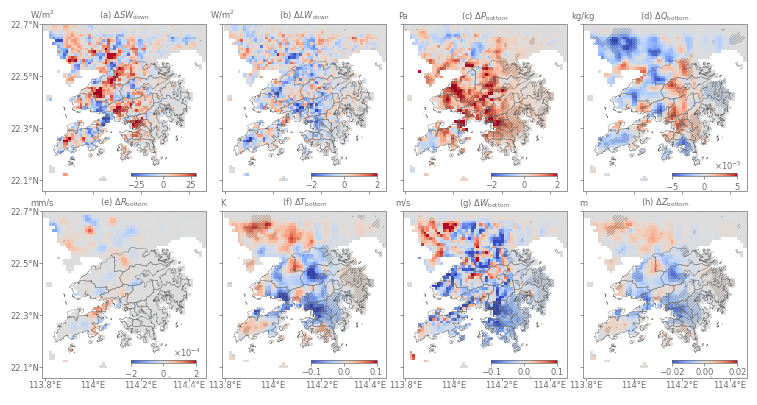

In [16]:
fig, axes = plt.subplots(nrows, ncols, figsize=(7.5, 3.9), subplot_kw={'projection': proj})
ax = axes.flatten()
for i in range(nrows * ncols):
    mete_var = mete_var_list[i]
    vmax = vmax_list[i]
    vmin = -vmax
    gdp_hk.plot(ax=ax[i], facecolor='none', edgecolor=labelcolor, lw=0.25, zorder=2)
    cm = ax[i].pcolormesh(lon, lat, data[i][mete_var], cmap=cmap, transform=proj, vmin=vmin, vmax=vmax)
    significant_mask = p_val_list[i]<0.05
    ax[i].contourf(lon, lat, significant_mask[mete_var], levels=[0.5, 1], colors='none', hatches=['/////////////'], alpha=0)   

    title = f'({string.ascii_lowercase[i]}) $\Delta${mete_varname_list[i]}'
    ax[i].set_title(title, fontsize = fontsize, pad=padding, color=labelcolor)
    
    for spine in ax[i].spines.values():
        spine.set_linewidth(boundarywidth)
        spine.set_edgecolor(labelcolor) 
    if i in [0, 4]:
        labelleft = True
    else:
        labelleft = False
    if i >=4:
        labelbottom = True
    else:
        labelbottom = False      
                
    ax[i].tick_params(axis='y', labelleft=labelleft, labelsize=labelsize, length=tick_length/2, 
                      pad=ticklabel_pad, width=boundarywidth, colors=labelcolor)
    ax[i].tick_params(axis='x', labelbottom=labelbottom, labelsize=labelsize, length=tick_length/2, 
                      pad=ticklabel_pad, width=boundarywidth, colors=labelcolor) 
    ax[i].set_extent(extent, crs=proj)
    xticks = np.arange(extent[0], extent[1], 0.2)
    xticks_round1 = np.round(xticks, 1)
    ax[i].set_xticks(xticks_round1, crs=proj)
    ax[i].set_xticklabels([f"{x:.1f}" for x in xticks], fontsize=labelsize, color=labelcolor)
    ax[i].xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=False))    
    yticks = np.arange(extent[2], extent[3], 0.2)
    yticks_round1 = np.round(yticks, 1)
    ax[i].set_yticks(yticks_round1, crs = proj) 
    ax[i].set_yticklabels([f"{y:.1f}" for y in yticks], fontsize=labelsize, color=labelcolor)
    ax[i].yaxis.set_major_formatter(LatitudeFormatter())
    ax[i].set_ylabel(unit_list[i], labelpad=5, rotation=0, ha='center', fontsize=fontsize,color=labelcolor)
    ax[i].yaxis.set_label_coords(0, 1.02)
    cbar = plt.colorbar(cm, ax=ax[i], orientation='horizontal',  extend='neither', shrink=0.4, fraction=0.1, 
                        pad=cbar_pad, anchor=(0.9, 1))
    offset_text = cbar.ax.yaxis.get_offset_text()
    offset_text.set(size=labelsize, color=labelcolor)
    offset_text.set_position((5, 2))
    cbar.ax.tick_params(length=2,labelsize=labelsize, pad=1, width=boundarywidth, colors=labelcolor)
    cbar.outline.set_linewidth(boundarywidth)
    cbar.outline.set_edgecolor(labelcolor)
    #cbar.ax.yaxis.label.set_color(labelcolor)
    if i in [3,4]:
        cbar.ax.ticklabel_format(style='scientific', scilimits=(0,0), axis='x')
        cbar.ax.xaxis.major.formatter._useMathText = True
        cbar.ax.xaxis.offsetText.set_color('white')
        cbar.ax.xaxis.offsetText.set_fontsize(fontsize)
        cbar.ax.xaxis.offsetText.set_position((1, -0.5))
        if i==3:
            factor=r'$\times 10^{-5}$'
        elif i==4:
            factor=r'$\times 10^{-4}$'   
        ax[i].text(0.8, 0.125, factor, transform=ax[i].transAxes, fontsize=fontsize, color=labelcolor)
mpl.rcParams['hatch.linewidth'] = 0.15  # adjust the hatch line widths
plt.subplots_adjust(left=0.05, right=0.99, bottom=0.035, top=0.97, wspace=0.1, hspace=0.05)  
plt.savefig('mete_change.png', dpi=300)
plt.savefig('mete_change.pdf', dpi=600)

# Description

In [6]:
ds_mask_hk = xr.open_dataset(f'{project_path}HK/mask/mask_HK_lat_lon.nc')
ds_mask_hk

<xarray.Dataset> Size: 33kB
Dimensions:    (lat: 60, lon: 60)
Coordinates:
  * lat        (lat) float64 480B 22.06 22.07 22.08 22.09 ... 22.67 22.68 22.69
  * lon        (lon) float64 480B 113.8 113.8 113.8 113.8 ... 114.4 114.5 114.5
Data variables:
    mask       (lat, lon) bool 4kB ...
    PCT_URBAN  (lat, lon) float64 29kB ...

In [7]:
for m, mete_var in enumerate(mete_var_list):
    ds_var = data[m][mete_var].where(ds_mask_hk['mask']==1)
    print(mete_var, np.round(ds_var.mean().values, 3))

FSDS 2.699
FLDS -0.136
PBOT 0.589
QBOT 0.0
RAIN 0.0
TBOT -0.014
WIND -0.022
ZBOT -0.002


In [8]:
ds_fsds = data[0]['FSDS'].where(ds_mask_hk['mask']==1)
ds_fsds

<xarray.DataArray 'FSDS' (lat: 60, lon: 60)> Size: 14kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(60, 60), dtype=float32)
Coordinates:
  * lon      (lon) float32 240B 113.8 113.8 113.8 113.8 ... 114.4 114.5 114.5
  * lat      (lat) float32 240B 22.06 22.07 22.08 22.09 ... 22.67 22.68 22.69

In [12]:
np.round(ds_fsds.mean(),1)

<xarray.DataArray 'FSDS' ()> Size: 4B
array(2.1, dtype=float32)